In [ ]:
import pandas as pd
import os

In [4]:
df = pd.read_csv('placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
df = df.iloc[:, 1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pylab as plt

findfont: Failed to find font weight normal, now using 700.


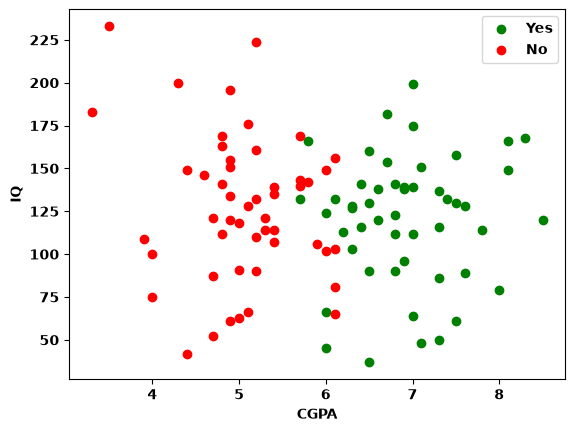

In [10]:
plt.scatter(df[df['placement']==1]['cgpa'],
            df[df['placement']==1]['iq'],
            color='green',
            label='Yes')

plt.scatter(df[df['placement']==0]['cgpa'],
            df[df['placement']==0]['iq'],
            color='red',
            label='No')

plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.legend()
plt.show()

In [11]:
X = df.iloc[:, 0:2]
Y = df.iloc[:,-1]
print(X)
print("Shape of X: ",X.shape)
print(Y)
print("Shape of Y: ",Y.shape)

    cgpa     iq
0    6.8  123.0
1    5.9  106.0
2    5.3  121.0
3    7.4  132.0
4    5.8  142.0
..   ...    ...
95   4.3  200.0
96   4.4   42.0
97   6.7  182.0
98   6.3  103.0
99   6.2  113.0

[100 rows x 2 columns]
Shape of X:  (100, 2)
0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64
Shape of Y:  (100,)


# Train test split 

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_text, Y_train, Y_text = train_test_split(X,Y,test_size=0.1)

In [13]:
X_train

,cgpa,iq
47,5.2,161.0
69,8.5,120.0
98,6.3,103.0
44,7.5,61.0
43,6.8,141.0
...,...,...
11,6.9,138.0
7,5.0,63.0
75,4.8,169.0
9,5.1,66.0


In [14]:
X_text

,cgpa,iq
35,6.8,90.0
24,4.7,121.0
40,4.9,134.0
21,7.1,151.0
30,7.6,128.0
82,6.5,37.0
48,6.6,138.0
45,6.0,66.0
58,8.0,79.0
76,4.9,155.0


In [15]:
Y_train

47    0
69    1
98    1
44    1
43    1
     ..
11    1
7     0
75    0
9     0
12    0
Name: placement, Length: 90, dtype: int64

In [16]:
Y_text

35    1
24    0
40    0
21    1
30    1
82    1
48    1
45    1
58    1
76    0
Name: placement, dtype: int64

# Scale the Test Splits

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [18]:
X_train

array([[-0.66499414,  0.90462018],
       [ 2.23946556, -0.1285115 ],
       [ 0.30315909, -0.55688318],
       [ 1.35932626, -1.61521319],
       [ 0.74322875,  0.40065351],
       [ 0.0391173 , -0.02771817],
       [-0.22492449,  0.37545517],
       [ 1.88740984,  0.60224018],
       [-1.19307772,  0.52664517],
       [ 0.30315909,  0.04787683],
       [ 0.12713123,  0.77862851],
       [ 0.74322875, -0.0529165 ],
       [-2.16123096,  2.71890021],
       [-0.04889663, -0.48128817],
       [-1.36910558, -2.09398153],
       [-0.57698021, -0.10331317],
       [-0.66499414,  0.1738685 ],
       [ 1.1832984 ,  0.29986017],
       [ 1.35932626,  0.12347184],
       [-1.7211613 , -0.63247818],
       [ 0.56720088, -0.1285115 ],
       [-0.13691056,  1.03061185],
       [-0.22492449,  1.10620685],
       [-0.48896628, -0.2797015 ],
       [ 0.12713123, -0.55688318],
       [ 0.47918695, -0.88446151],
       [-0.92903593,  1.78656186],
       [ 1.1832984 , -0.98525485],
       [-0.13691056,

In [19]:
X_text = scaler.fit_transform(X_text)
X_text 

array([[ 0.44418985, -0.52926842],
       [-1.45948095,  0.29522007],
       [-1.27817897,  0.64097332],
       [ 0.71614283,  1.09311217],
       [ 1.16939778,  0.4813949 ],
       [ 0.17223688, -1.93887779],
       [ 0.26288787,  0.74735893],
       [-0.28101807, -1.1675821 ],
       [ 1.53200174, -0.82182886],
       [-1.27817897,  1.19949778]])

# Model Training

In [20]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [21]:
clf.predict(X_text)

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [22]:
Y_text

35    1
24    0
40    0
21    1
30    1
82    1
48    1
45    1
58    1
76    0
Name: placement, dtype: int64

In [23]:
Y_pred = clf.predict(X_text)
Y_pred 

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [24]:
# Accuracy Score

from sklearn.metrics import accuracy_score

accuracy_score(Y_text, Y_pred)

0.9

In [25]:

from mlxtend.plotting import plot_decision_regions

<Axes: >

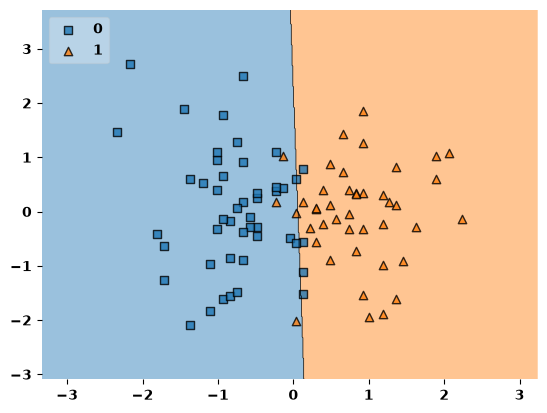

In [26]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [27]:
import pickle

In [28]:
pickle.dump(clf,open('model.pkl', 'wb'))